[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaimeHuaytallaPariona/ingenieria-conocimiento-uncp/blob/master/recursos/sesion_02_modelos_clasificacion.ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Alumno:** Gomez Muñoz David Pedro           
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [53]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


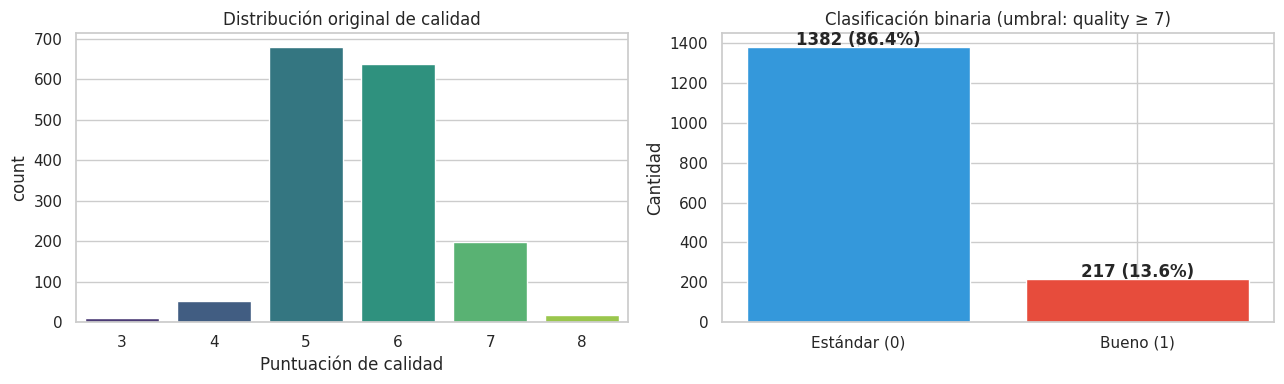


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [54]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [55]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


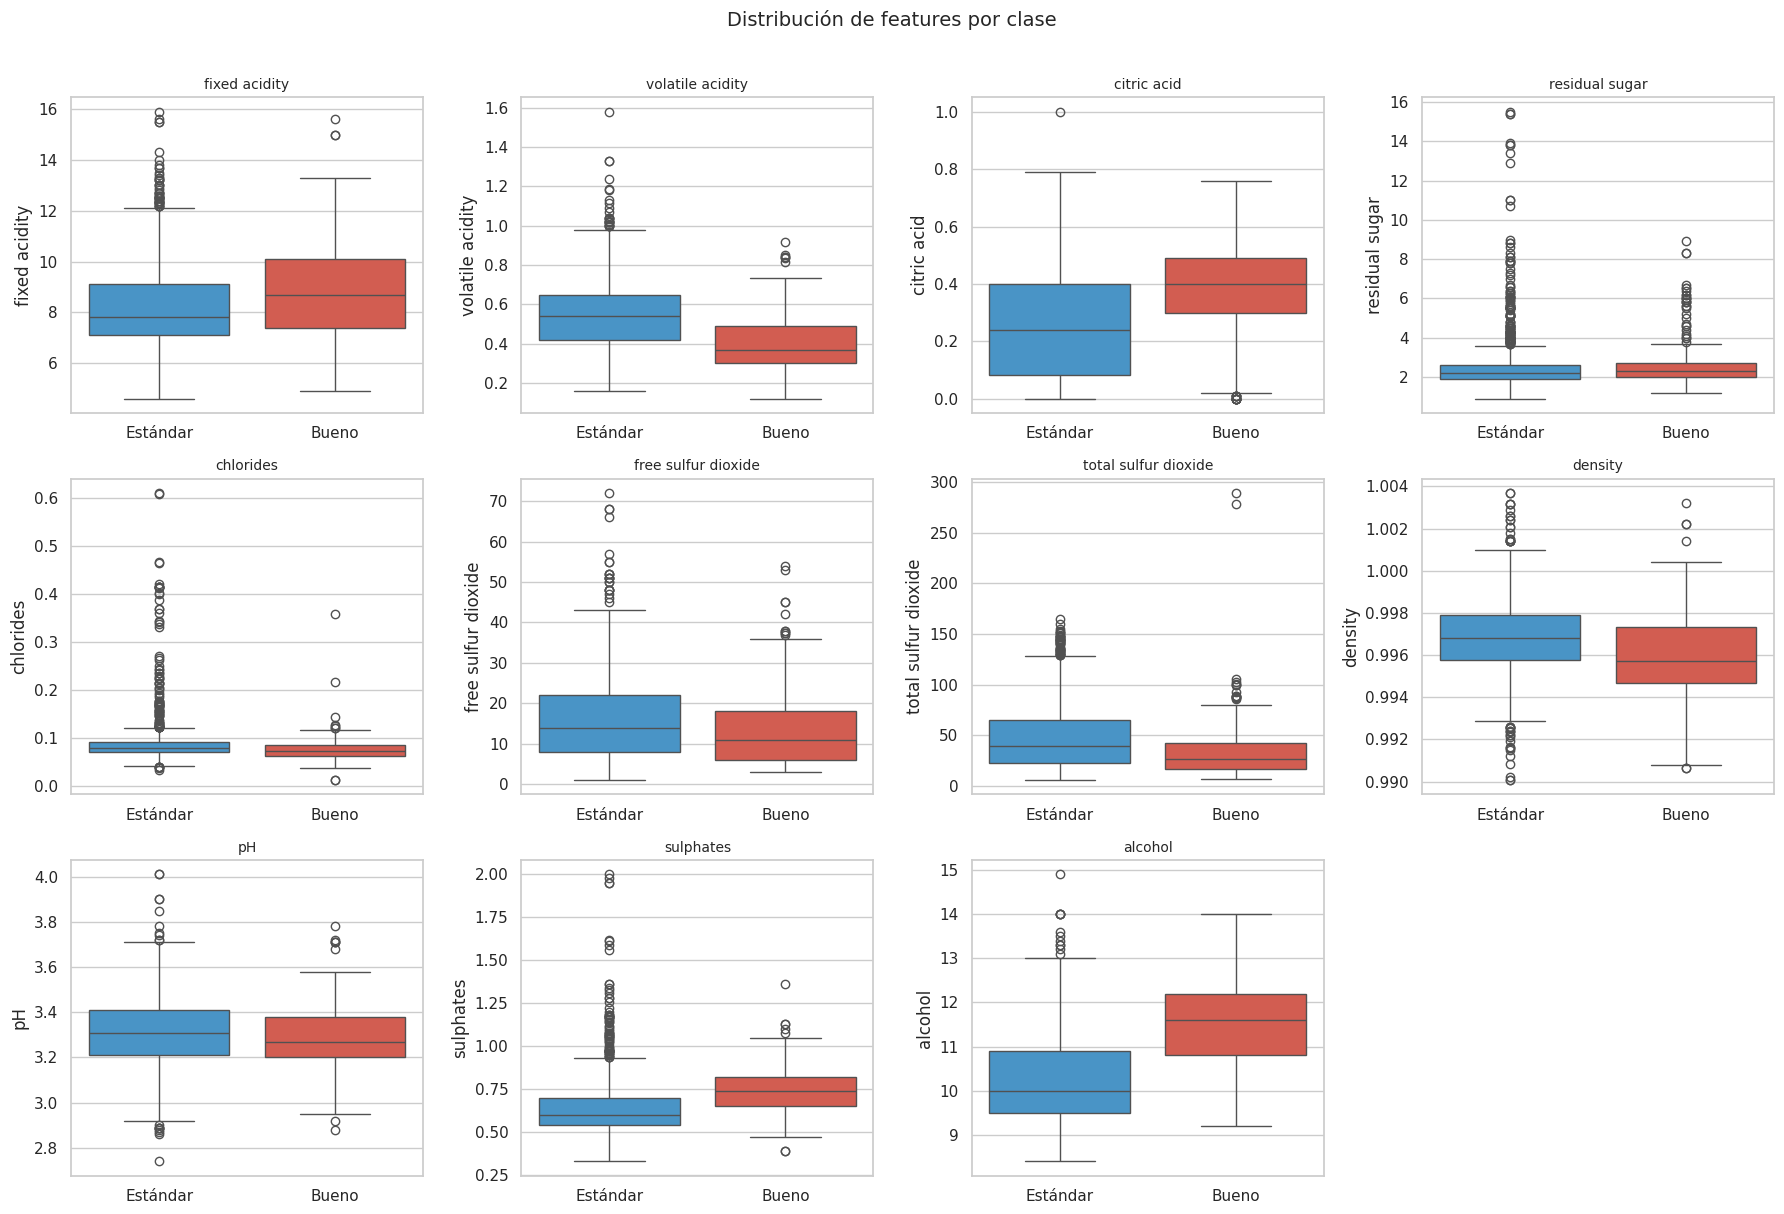

In [56]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

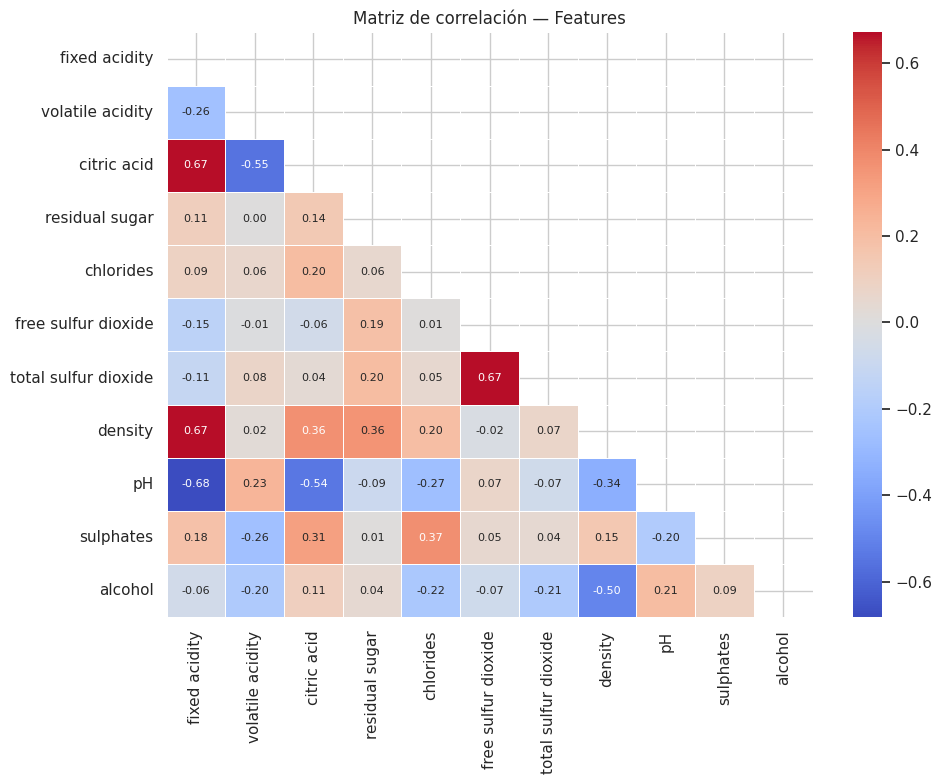

In [6]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [7]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [8]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [9]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


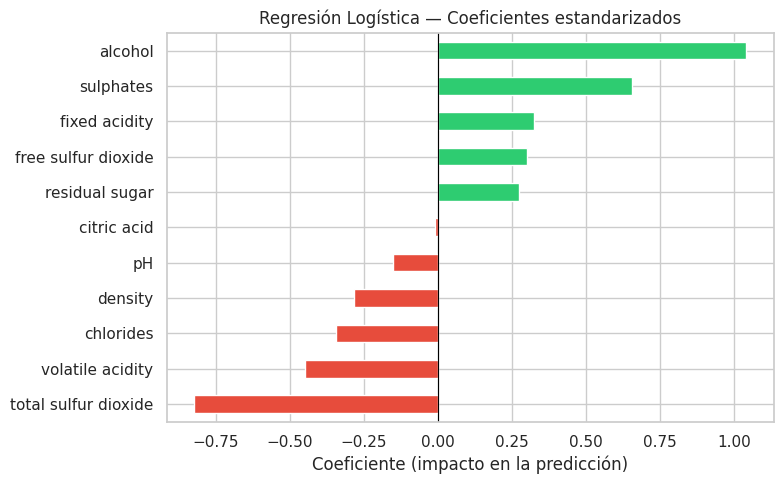


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [10]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [11]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


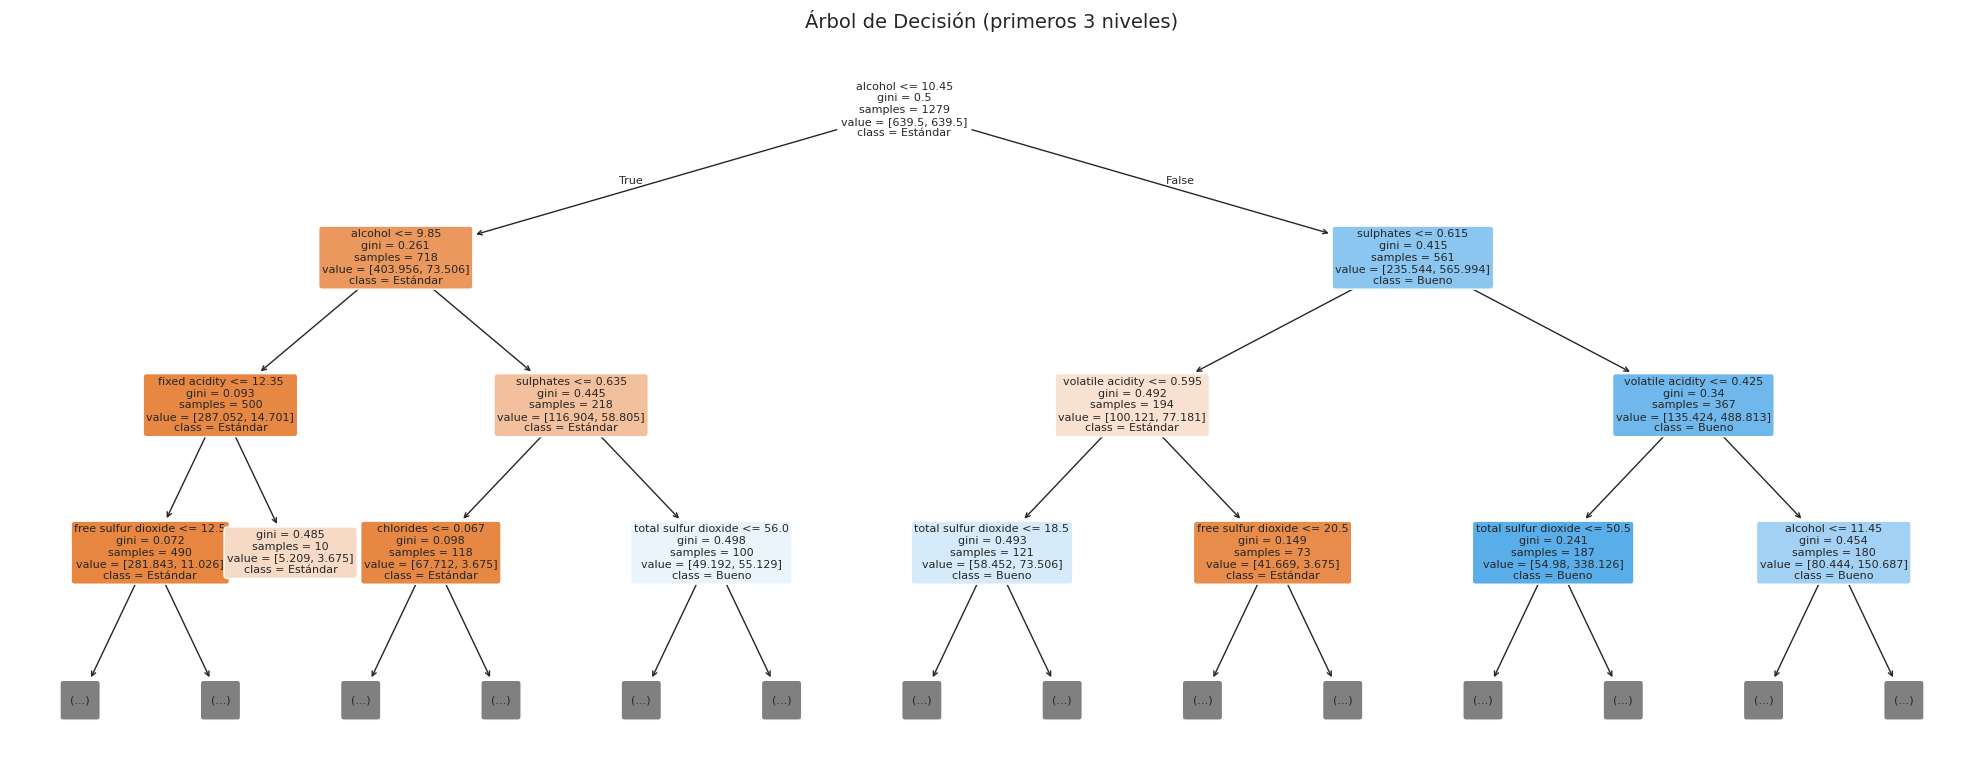

In [12]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

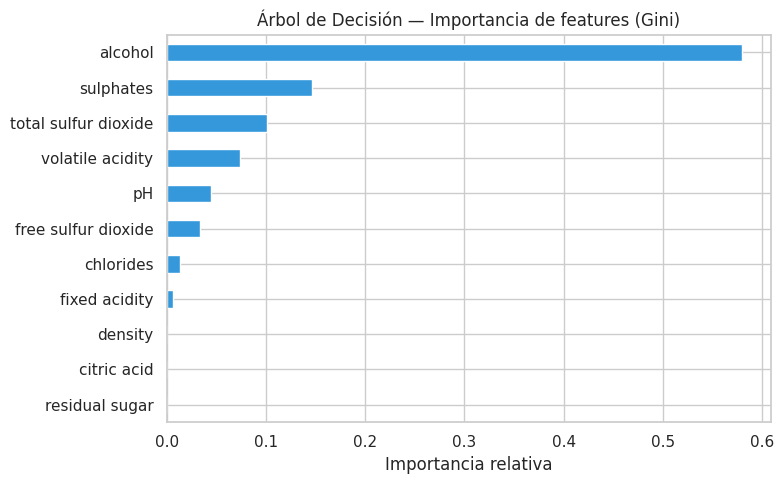

In [13]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

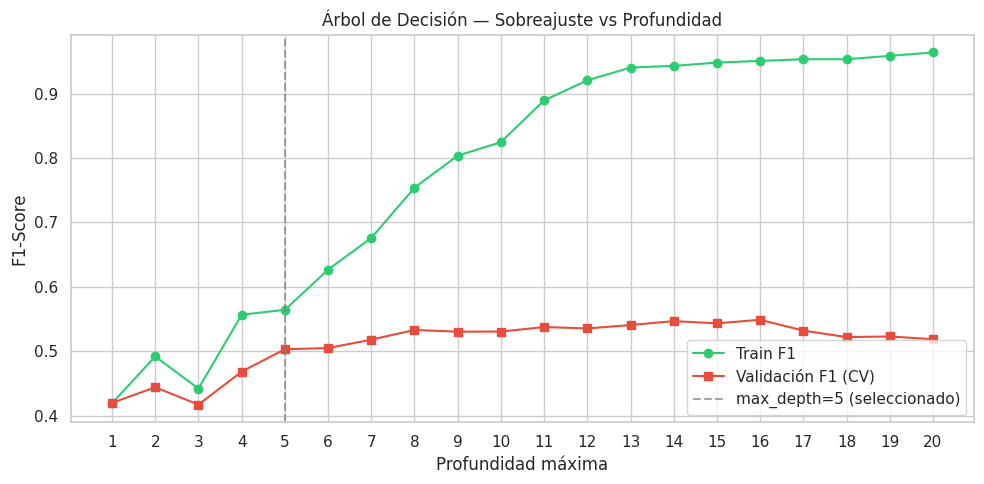

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [14]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [15]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [16]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [17]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

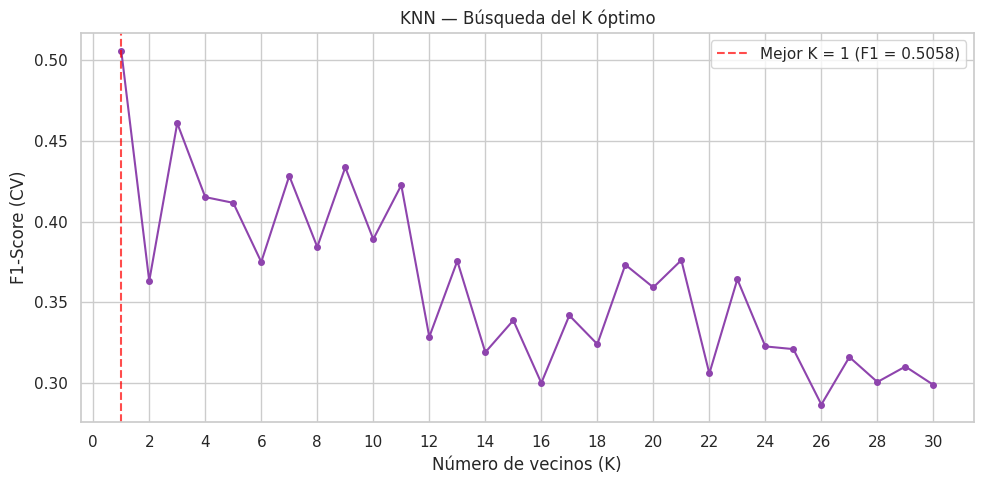

K óptimo: 1


In [18]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [19]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [20]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


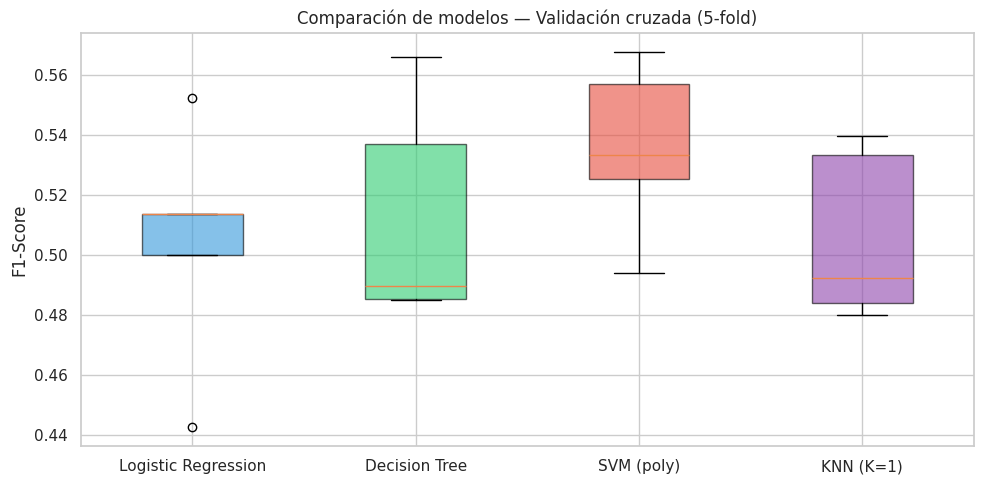

In [21]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

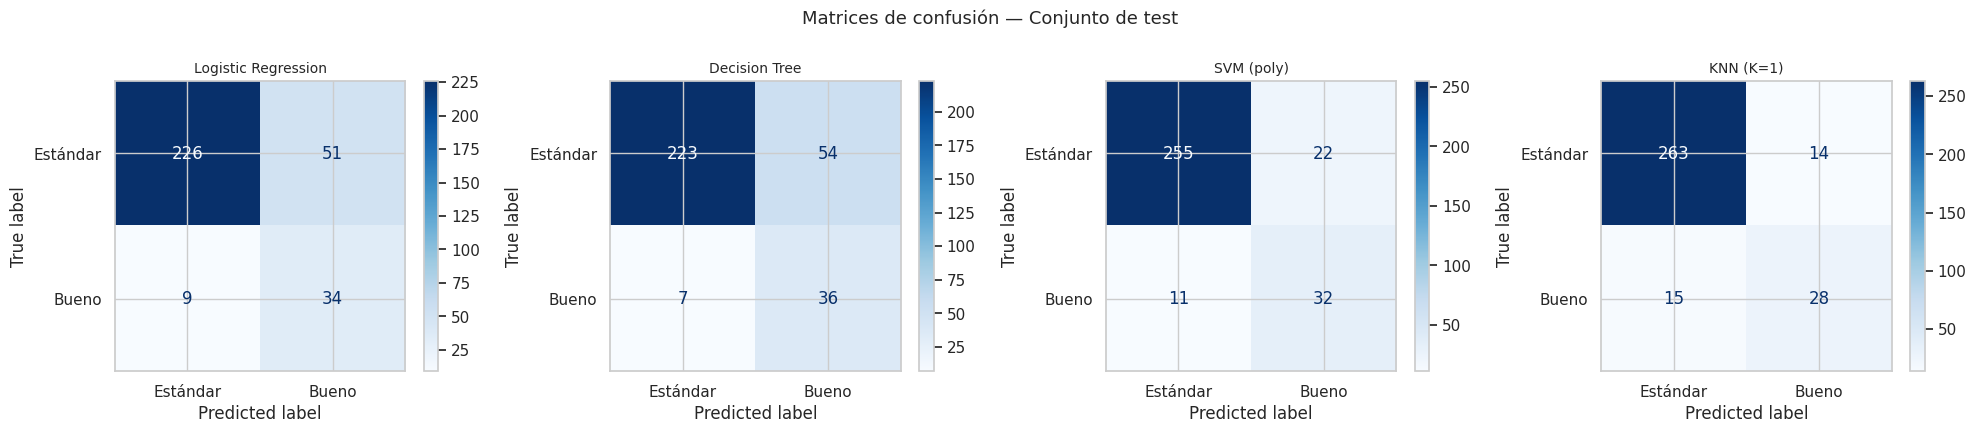

In [22]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

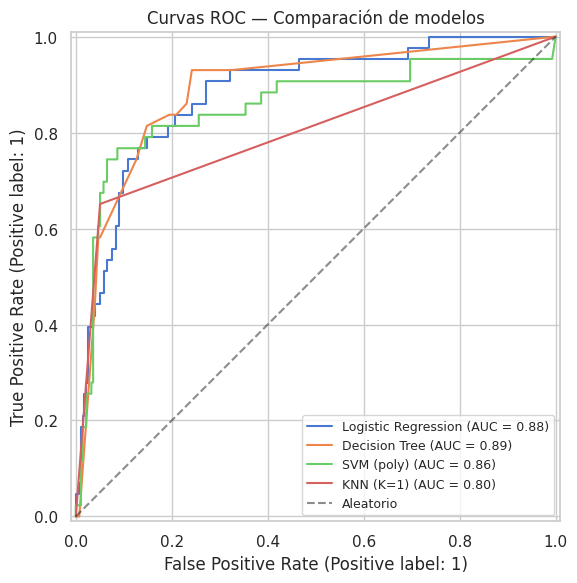

In [23]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
##Resolución de los ejercicios propuestos
Los ejercicios 1 y 2 usan las variables de la sesión (hay que ejecutar antes las celdas anteriores). El ejercicio 3 necesita el archivo `wdbc.data` en la carpeta del notebook (en Colab, subirlo al panel de archivos).

In [25]:
# 12.0  Importaciones adicionales (solo métricas de sklearn)
from sklearn.metrics import precision_score, recall_score, roc_auc_score

### Resolucion del ejeercicio 1


In [26]:
# 12.1  GridSearchCV para SVM (misma validación cruzada `cv` y F1 de la sesión)
param_grid = {
    'clf__C':      [0.1, 1, 10, 100],
    'clf__gamma':  ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}

pipe_svm_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))
])

grid_svm = GridSearchCV(pipe_svm_gs, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_svm.fit(X_train, y_train)

res_gs = pd.DataFrame(grid_svm.cv_results_)
print('Mejores hiperparámetros:', grid_svm.best_params_)
print(f"Mejor F1 CV: {grid_svm.best_score_:.4f} ± {res_gs.loc[grid_svm.best_index_, 'std_test_score']:.4f}")
print('\nF1 CV mínimo y máximo por kernel:')
print(res_gs.groupby('param_clf__kernel')['mean_test_score'].agg(['min', 'max']).round(4))

Mejores hiperparámetros: {'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}
Mejor F1 CV: 0.5450 ± 0.0413

F1 CV mínimo y máximo por kernel:
                      min     max
param_clf__kernel                
poly               0.1916  0.5406
rbf                0.4851  0.5450


In [27]:
# 12.2  Comparación contra el SVM base de la sesión
y_pred_gs = grid_svm.predict(X_test)

fila_base = res_gs[(res_gs['param_clf__kernel'] == best_kernel) &
                   (res_gs['param_clf__C'] == 1) & (res_gs['param_clf__gamma'] == 'scale')]
print(f"El SVM base ({best_kernel}, C=1, gamma='scale') quedó en el puesto "
      f"{int(fila_base['rank_test_score'].iloc[0])} de {len(res_gs)} combinaciones\n")

print('='*70)
print('SVM BASE vs SVM CON GRIDSEARCHCV')
print('='*70)
print(f'{"":18s} {"F1 CV":>7s} {"F1 Test":>8s} {"Accuracy":>9s} {"Precision":>10s} {"Recall":>7s}')
for nombre, y_pred, f1_cv in [('SVM base', y_pred_svm, scores_svm.mean()),
                              ('SVM GridSearchCV', y_pred_gs, grid_svm.best_score_)]:
    print(f'{nombre:18s} {f1_cv:7.4f} {f1_score(y_test, y_pred):8.4f} {accuracy_score(y_test, y_pred):9.4f} '
          f'{precision_score(y_test, y_pred):10.4f} {recall_score(y_test, y_pred):7.4f}')

El SVM base (poly, C=1, gamma='scale') quedó en el puesto 4 de 32 combinaciones

SVM BASE vs SVM CON GRIDSEARCHCV
                     F1 CV  F1 Test  Accuracy  Precision  Recall
SVM base            0.5355   0.6598    0.8969     0.5926  0.7442
SVM GridSearchCV    0.5450   0.6422    0.8781     0.5303  0.8140


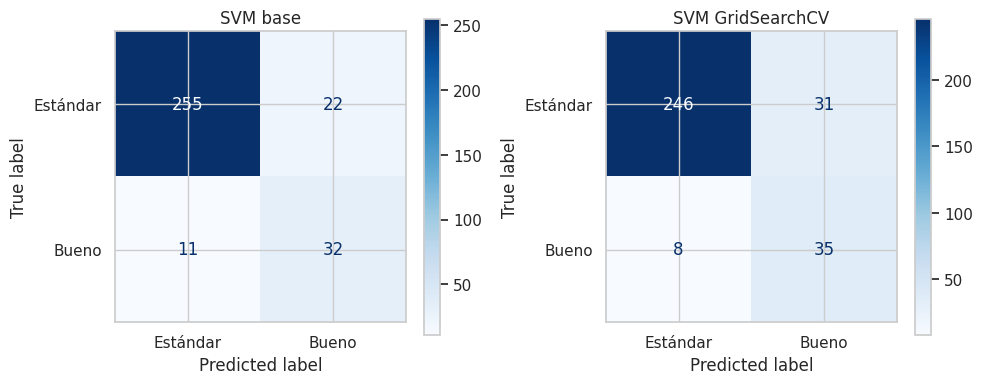

In [28]:
# 12.3  Matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nombre, y_pred) in zip(axes, [('SVM base', y_pred_svm), ('SVM GridSearchCV', y_pred_gs)]):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
        display_labels=['Estándar', 'Bueno'], cmap='Blues', ax=ax)
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

#### Reporte de resultados

**Mejores hiperparámetros** (GridSearchCV, 32 combinaciones evaluadas):

| Hiperparámetro | Valor |
|---|---|
| `kernel` | rbf |
| `C` | 10 |
| `gamma` | 0.1 |

**F1-score obtenido:** 0.5450 ± 0.0413 en validación cruzada (5 folds) y 0.6422 en el conjunto de test.

**Comparación contra el SVM base de la sesión** (kernel poly, `C=1`, `gamma='scale'`):

| Modelo | F1 CV | F1 Test | Accuracy | Precision | Recall |
|---|---|---|---|---|---|
| SVM base | 0.5355 | 0.6598 | 0.8969 | 0.5926 | 0.7442 |
| SVM GridSearchCV | 0.5450 | 0.6422 | 0.8781 | 0.5303 | 0.8140 |

- En validación cruzada el F1 del modelo ajustado subió 0.0095 (de 0.5355 a 0.5450). Es una diferencia menor que la variación entre folds (± 0.0413), y el SVM base ya estaba en el puesto 4 de 32 combinaciones, así que no se puede considerar una mejora real.
- En el conjunto de test el modelo ajustado no mejoró: el F1 bajó de 0.6598 a 0.6422 y el accuracy de 0.8969 a 0.8781.
- Lo que cambió fue el tipo de error: el recall subió (de 0.7442 a 0.8140), es decir, encuentra más vinos "Bueno", pero la precision bajó (de 0.5926 a 0.5303), es decir, da más falsas alarmas.
- En resumen, GridSearchCV no mejoró de forma clara al SVM base: los dos modelos rinden de manera parecida.

### Resolución del ejercicio 2


In [29]:
# 13.1  Clases originales de quality (3–8) y split estratificado 80/20
y_multi = df['quality'].copy()

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.20, random_state=RANDOM_STATE, stratify=y_multi
)
clases = [int(c) for c in sorted(y_multi.unique())]

print(f'Train: {X_train_m.shape[0]} muestras  |  Test: {X_test_m.shape[0]} muestras\n')
print(pd.DataFrame({'Total': y_multi.value_counts().sort_index(),
                    'Train': y_train_m.value_counts().sort_index(),
                    'Test':  y_test_m.value_counts().sort_index()}))

Train: 1279 muestras  |  Test: 320 muestras

         Total  Train  Test
quality                    
3           10      8     2
4           53     42    11
5          681    545   136
6          638    510   128
7          199    159    40
8           18     15     3


In [30]:
# 13.2  Pipelines (mismos hiperparámetros de la sesión) y validación cruzada con F1 macro
pipelines_m = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                       class_weight='balanced', random_state=RANDOM_STATE))
    ])
}
for kernel in ['linear', 'rbf', 'poly']:
    pipelines_m[f'SVM ({kernel})'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced', random_state=RANDOM_STATE))
    ])

results_m = {}
for name, pipe in pipelines_m.items():
    scores = cross_val_score(pipe, X_train_m, y_train_m, cv=cv, scoring='f1_macro')
    results_m[name] = scores
    print(f'{name:22s}  F1 macro CV: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression     F1 macro CV: 0.2841 ± 0.0167
Decision Tree           F1 macro CV: 0.2224 ± 0.0207
SVM (linear)            F1 macro CV: 0.2700 ± 0.0061
SVM (rbf)               F1 macro CV: 0.2872 ± 0.0251
SVM (poly)              F1 macro CV: 0.3369 ± 0.0396


In [31]:
# 13.3  KNN: búsqueda del K óptimo y selección del mejor kernel de SVM
k_scores_m = []
for k in k_range:
    pipe_knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    k_scores_m.append(cross_val_score(pipe_knn, X_train_m, y_train_m, cv=cv, scoring='f1_macro').mean())

best_k_m = k_range[np.argmax(k_scores_m)]
best_kernel_m = max(['linear', 'rbf', 'poly'], key=lambda k: results_m[f'SVM ({k})'].mean())

print(f'K óptimo: {best_k_m}  (F1 macro CV = {max(k_scores_m):.4f})')
print(f'Mejor kernel de SVM: {best_kernel_m}')

K óptimo: 3  (F1 macro CV = 0.3282)
Mejor kernel de SVM: poly


In [32]:
# 13.4  Entrenamiento final y tabla resumen (F1 micro / macro / weighted)
pipe_knn_m = Pipeline([('scaler', StandardScaler()),
                       ('clf', KNeighborsClassifier(n_neighbors=best_k_m))])
results_m[f'KNN (K={best_k_m})'] = cross_val_score(pipe_knn_m, X_train_m, y_train_m,
                                                   cv=cv, scoring='f1_macro')
models_m = {
    'Logistic Regression':    pipelines_m['Logistic Regression'],
    'Decision Tree':          pipelines_m['Decision Tree'],
    f'SVM ({best_kernel_m})': pipelines_m[f'SVM ({best_kernel_m})'],
    f'KNN (K={best_k_m})':    pipe_knn_m
}

preds_m, summary_m = {}, []
for name, pipe in models_m.items():
    pipe.fit(X_train_m, y_train_m)
    y_pred = pipe.predict(X_test_m)
    preds_m[name] = y_pred
    summary_m.append({
        'Modelo': name,
        'F1 macro CV': f'{results_m[name].mean():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test_m, y_pred):.4f}',
        'F1 micro': f'{f1_score(y_test_m, y_pred, average="micro"):.4f}',
        'F1 macro': f'{f1_score(y_test_m, y_pred, average="macro"):.4f}',
        'F1 weighted': f'{f1_score(y_test_m, y_pred, average="weighted"):.4f}'
    })

print('='*85)
print('COMPARACIÓN DE MODELOS — MULTICLASE (quality 3–8)')
print('='*85)
print(pd.DataFrame(summary_m).to_string(index=False))

print('\nReferencia — versión binaria de la sesión:')
print(summary_df[['Modelo', 'Accuracy Test', 'F1 Test']].to_string(index=False))

COMPARACIÓN DE MODELOS — MULTICLASE (quality 3–8)
             Modelo F1 macro CV Accuracy Test F1 micro F1 macro F1 weighted
Logistic Regression      0.2841        0.3969   0.3969   0.2402      0.4408
      Decision Tree      0.2224        0.3969   0.3969   0.2702      0.4089
         SVM (poly)      0.3369        0.5687   0.5687   0.3346      0.5837
          KNN (K=3)      0.3282        0.5750   0.5750   0.2949      0.5698

Referencia — versión binaria de la sesión:
             Modelo Accuracy Test F1 Test
Logistic Regression        0.8125  0.5312
      Decision Tree        0.8094  0.5414
         SVM (poly)        0.8969  0.6598
          KNN (K=1)        0.9094  0.6588


In [33]:
# 13.5  F1 por clase
f1_clase = pd.DataFrame(
    {name: f1_score(y_test_m, y_pred, labels=clases, average=None, zero_division=0)
     for name, y_pred in preds_m.items()},
    index=clases
)
f1_clase['Soporte test'] = y_test_m.value_counts().sort_index()
print('F1 por clase (test):')
print(f1_clase.round(3))

F1 por clase (test):
   Logistic Regression  Decision Tree  SVM (poly)  KNN (K=3)  Soporte test
3                0.000          0.133       0.000      0.000             2
4                0.100          0.087       0.235      0.000            11
5                0.575          0.645       0.644      0.640           136
6                0.354          0.197       0.585      0.569           128
7                0.412          0.405       0.543      0.560            40
8                0.000          0.154       0.000      0.000             3


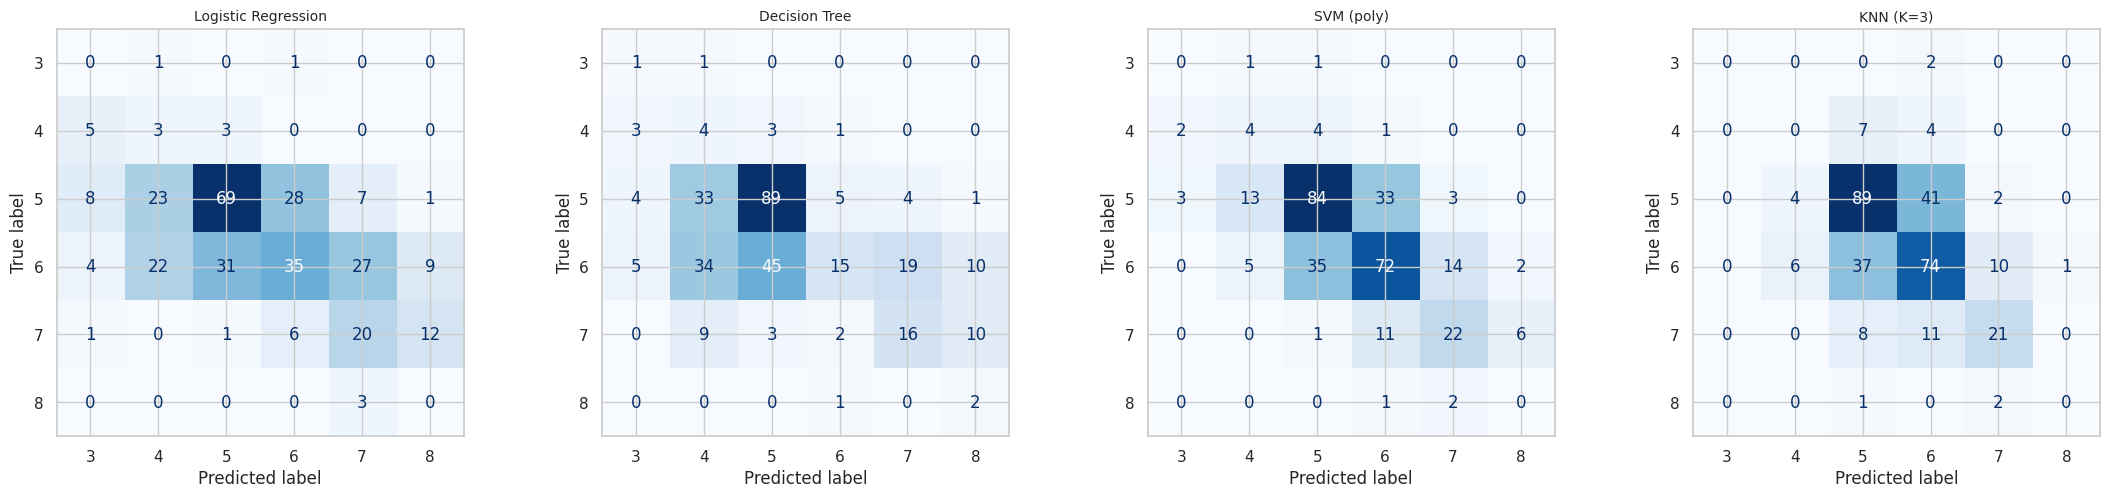

Errores que caen a una sola calidad de distancia (±1):
  Logistic Regression     72.0% de 193 errores
  Decision Tree           62.7% de 193 errores
  SVM (poly)              87.7% de 138 errores
  KNN (K=3)               82.4% de 136 errores


In [34]:
# 13.6  Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, y_pred) in zip(axes, preds_m.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_m, y_pred, labels=clases, cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

print('Errores que caen a una sola calidad de distancia (±1):')
for name, y_pred in preds_m.items():
    err = y_pred != y_test_m.values
    dif = np.abs(y_pred[err] - y_test_m.values[err])
    print(f'  {name:22s} {np.mean(dif == 1)*100:5.1f}% de {err.sum()} errores')

#### Análisis

**1. ¿Cómo cambia el rendimiento de cada modelo?**

| Modelo | Accuracy binario | Accuracy multiclase | F1 binario (clase "Bueno") | F1 macro multiclase |
|---|---|---|---|---|
| Logistic Regression | 0.8125 | 0.3969 | 0.5312 | 0.2402 |
| Decision Tree | 0.8094 | 0.3969 | 0.5414 | 0.2702 |
| SVM (poly) | 0.8969 | 0.5687 | 0.6598 | 0.3346 |
| KNN | 0.9094 (K=1) | 0.5750 (K=3) | 0.6588 | 0.2949 |

- Los cuatro modelos empeoran mucho al pasar de 2 a 6 clases: el accuracy baja de 0.81–0.91 a 0.40–0.575. No es una comparación exacta porque el problema cambió, pero muestra que ahora es bastante más difícil.
- El SVM (poly) fue el más consistente: mayor F1 macro en validación cruzada (0.3369), mayor F1 macro en test (0.3346) y mayor F1 weighted (0.5837).
- KNN (K=3) tuvo el accuracy más alto (0.5750) y un F1 macro de CV de 0.3282, pero su F1 macro en test bajó a 0.2949.
- La Regresión Logística y el Árbol de Decisión quedaron últimos: su accuracy (0.3969) es menor que el de predecir siempre la calidad "5" (136 de 320 vinos del test = 0.425). El Árbol tuvo además el F1 macro de CV más bajo (0.2224).

**2. ¿Qué clases son más difíciles de distinguir?**

- **Las clases 3 y 8 son las más difíciles.** La Regresión Logística, el SVM y KNN sacan F1 = 0 en ambas; el Árbol solo llega a 0.133 y 0.154. Tienen muy pocos ejemplos: 10 y 18 vinos en total, y solo 2 y 3 en el test.
- **La clase 4 también es difícil:** su F1 va de 0 a 0.235 según el modelo (11 vinos en el test).
- **La clase 5 es la más fácil** (F1 entre 0.575 y 0.645), seguida de la 7 y la 6 en SVM y KNN. La clase 6 le cuesta mucho a la Regresión Logística (0.354) y al Árbol (0.197).
- Los errores casi siempre son "por poco": caen en la calidad vecina el 87.7 % de los errores del SVM, el 82.4 % de KNN, el 72.0 % de la Regresión Logística y el 62.7 % del Árbol. Por ejemplo, en el SVM se confunden mucho los vinos de calidad 5 con los de calidad 6.

**3. ¿Qué métrica de F1 es más adecuada? Justificación**

La más adecuada es **macro**, por estas razones:

- El **micro** sale idéntico al accuracy en los cuatro modelos (0.3969, 0.3969, 0.5687 y 0.5750), así que no aporta información nueva.
- El **weighted** está dominado por las clases 5 y 6, que son el 82.5 % del test. Por eso el SVM parece tener un desempeño aceptable (0.5837) aunque sus clases 3 y 8 tienen F1 = 0.
- El **macro** da el mismo peso a las 6 clases y sí refleja esas fallas (SVM: 0.3346). Como el problema está desbalanceado y las clases raras también importan, es la métrica más justa.
- Una limitación: con solo 2 y 3 vinos de las clases 3 y 8 en el test, el F1 macro de test es inestable. Por eso el kernel del SVM y el K de KNN se eligieron con el F1 macro de validación cruzada.rnel y el K se eligieron con el F1 macro de validación cruzada.

### Ejercicio 3 — Aplicación con dataset propio: Breast Cancer Wisconsin (Diagnostic)
Usamos el archivo `wdbc.data` (569 tumores de mama y 30 features numéricas) para clasificar cada tumor como **benigno (0)** o **maligno (1)**.

In [36]:
import requests

# URL del dataset wdbc.data en el repositorio de la UCI
url_wdbc = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data'

# Nombre del archivo local
file_name_wdbc = 'wdbc.data'

# Descargar el archivo
try:
    response = requests.get(url_wdbc)
    response.raise_for_status()  # Lanza un error si la solicitud HTTP no fue exitosa
    with open(file_name_wdbc, 'wb') as f:
        f.write(response.content)
    print(f'El archivo "{file_name_wdbc}" ha sido descargado exitosamente.')
except requests.exceptions.RequestException as e:
    print(f'Error al descargar el archivo: {e}')
except Exception as e:
    print(f'Ocurrió un error: {e}')

El archivo "wdbc.data" ha sido descargado exitosamente.


#### Carga y revisión de datos
El archivo no trae encabezado, así que los nombres se asignan al leerlo. Las 30 features son 10 medidas de las células (radio, textura, perímetro, área, etc.) en tres versiones: `_mean`, `_se` y `_worst`. `Diagnosis` viene como M/B y se convierte a 1/0 con Python; el `ID` solo identifica el registro, por eso se excluye de las features.

In [37]:
# 14.1  Carga del dataset wdbc.data (no tiene encabezado; el archivo no se modifica)
base_names = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
              'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
columnas_bc = (['ID', 'Diagnosis']
               + [f'{n}_{s}' for s in ['mean', 'se', 'worst'] for n in base_names])

df_bc = pd.read_csv('wdbc.data', header=None, names=columnas_bc)
print(f'Dataset cargado: {df_bc.shape[0]} registros, {df_bc.shape[1]} columnas')
df_bc.iloc[:, :8].head()

Dataset cargado: 569 registros, 32 columnas


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280


In [38]:
# 14.2  Revisión inicial: tipos, nulos, duplicados y variable objetivo original
print('Tipos de datos:')
print(df_bc.dtypes.value_counts())
print(f"\nValores nulos: {df_bc.isnull().sum().sum()}")
print(f"Registros duplicados: {df_bc.duplicated().sum()}  |  IDs repetidos: {df_bc['ID'].duplicated().sum()}")
print("\nDiagnosis original:")
print(df_bc['Diagnosis'].value_counts())

Tipos de datos:
float64    30
int64       1
object      1
Name: count, dtype: int64

Valores nulos: 0
Registros duplicados: 0  |  IDs repetidos: 0

Diagnosis original:
Diagnosis
B    357
M    212
Name: count, dtype: int64


In [39]:
# 14.3  Conversión de Diagnosis (M -> 1, B -> 0) y separación de X / y
df_bc['Diagnosis'] = df_bc['Diagnosis'].map({'M': 1, 'B': 0})

assert set(df_bc['Diagnosis'].unique()) == {0, 1}   # solo 0 y 1, sin valores perdidos
print('Valores únicos de Diagnosis:', sorted(df_bc['Diagnosis'].unique().tolist()))
print(df_bc['Diagnosis'].value_counts().sort_index())

# El ID solo identifica al registro: no se usa como feature
X_bc = df_bc.drop(columns=['ID', 'Diagnosis'])
y_bc = df_bc['Diagnosis']

print(f"\nFeatures: {X_bc.shape}  |  Target: {y_bc.shape}  |  ¿ID en X_bc? {'ID' in X_bc.columns}")

Valores únicos de Diagnosis: [0, 1]
Diagnosis
0    357
1    212
Name: count, dtype: int64

Features: (569, 30)  |  Target: (569,)  |  ¿ID en X_bc? False


#### Exploración
Vemos cómo están repartidas las clases, qué features se parecen entre sí y cuáles cambian más entre tumores benignos y malignos.

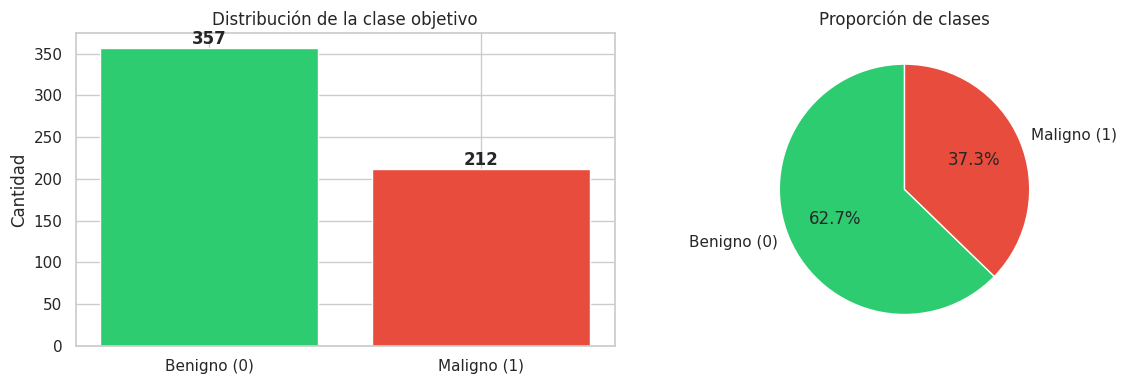

Ratio de desbalance: 1.68:1 (Benigno vs Maligno)


In [40]:
# 14.4  Distribución de la clase objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = y_bc.value_counts().sort_index()
axes[0].bar(['Benigno (0)', 'Maligno (1)'], target_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Benigno (0)', 'Maligno (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()
print(f'Ratio de desbalance: {target_counts[0]/target_counts[1]:.2f}:1 (Benigno vs Maligno)')

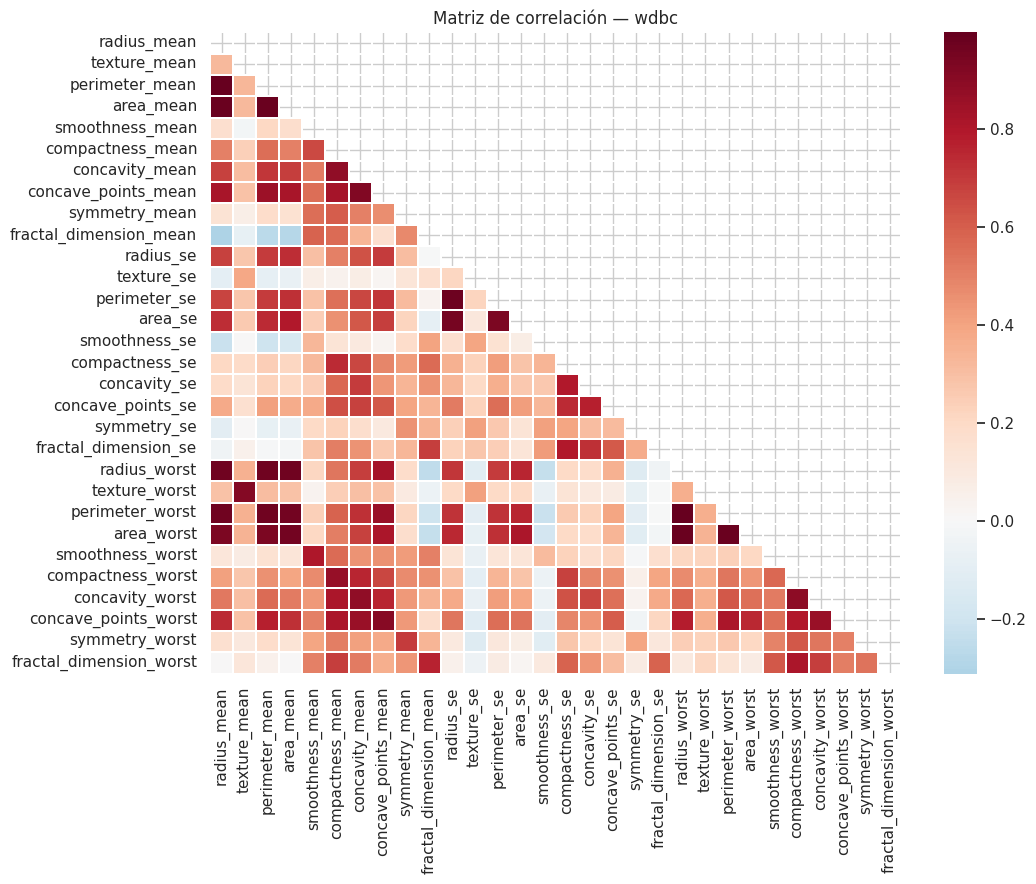

Pares de features con |r| >= 0.90: 21 de 435

Mayor diferencia entre maligno y benigno (% sobre la media benigna):
concavity_mean         249.1
area_se                243.8
concave_points_mean    242.1
concavity_worst        171.1
area_worst             154.5

Menor diferencia:
texture_se               -0.8
symmetry_se              -0.5
fractal_dimension_mean   -0.3


In [41]:
# 14.5  Correlación entre features y diferencias entre clases
plt.figure(figsize=(11, 9))
corr_bc = X_bc.corr()
mask = np.triu(np.ones_like(corr_bc, dtype=bool))
sns.heatmap(corr_bc, mask=mask, cmap='RdBu_r', center=0, linewidths=0.2)
plt.title('Matriz de correlación — wdbc')
plt.tight_layout()
plt.show()

pares = corr_bc.where(~mask).stack().dropna()
print(f'Pares de features con |r| >= 0.90: {(pares.abs() >= 0.90).sum()} de {len(pares)}')

medias = df_bc.groupby('Diagnosis')[list(X_bc.columns)].mean().T
dif_pct = ((medias[1] - medias[0]) / medias[0] * 100).round(1)
orden = dif_pct.abs().sort_values(ascending=False).index
print('\nMayor diferencia entre maligno y benigno (% sobre la media benigna):')
print(dif_pct[orden].head(5).to_string())
print('\nMenor diferencia:')
print(dif_pct[orden].tail(3).to_string())

#### Preparación de datos
Mismo split estratificado 80/20 con `random_state=42`. La estandarización va dentro de los pipelines, solo en los modelos que la necesitan (el Árbol no).

In [42]:
# 14.6  División train / test (80-20, estratificado)
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.20, random_state=RANDOM_STATE, stratify=y_bc
)

print(f'Train: {X_train_bc.shape[0]} muestras  |  Test: {X_test_bc.shape[0]} muestras')
print(f'Proporción clase 1 (maligno) en train: {y_train_bc.mean():.3f}')
print(f'Proporción clase 1 (maligno) en test:  {y_test_bc.mean():.3f}')

print('\nEscalas (justifican la estandarización):')
for col in ['area_worst', 'smoothness_worst']:
    print(f'  {col:18s} de {X_train_bc[col].min():.4f} a {X_train_bc[col].max():.4f}')

Train: 455 muestras  |  Test: 114 muestras
Proporción clase 1 (maligno) en train: 0.374
Proporción clase 1 (maligno) en test:  0.368

Escalas (justifican la estandarización):
  area_worst         de 185.2000 a 4254.0000
  smoothness_worst   de 0.0712 a 0.2226


#### Entrenamiento de modelos
Los 4 modelos de la sesión con validación cruzada de 5 folds y F1: Regresión Logística, Árbol de Decisión, SVM (kernels lineal, rbf y poly) y KNN (K de 1 a 30).

In [43]:
# 14.7  Pipelines y validación cruzada (5-fold, F1)
pipelines_bc = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced'))
    ]),
    'Decision Tree': Pipeline([
        ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                       class_weight='balanced', random_state=RANDOM_STATE))
    ])
}
for kernel in ['linear', 'rbf', 'poly']:
    pipelines_bc[f'SVM ({kernel})'] = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced', random_state=RANDOM_STATE, probability=True))
    ])

results_bc = {}
for name, pipe in pipelines_bc.items():
    scores = cross_val_score(pipe, X_train_bc, y_train_bc, cv=cv, scoring='f1')
    results_bc[name] = scores
    print(f'{name:22s}  F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression     F1 CV: 0.9616 ± 0.0241
Decision Tree           F1 CV: 0.9255 ± 0.0296
SVM (linear)            F1 CV: 0.9523 ± 0.0159
SVM (rbf)               F1 CV: 0.9583 ± 0.0154
SVM (poly)              F1 CV: 0.8820 ± 0.0591


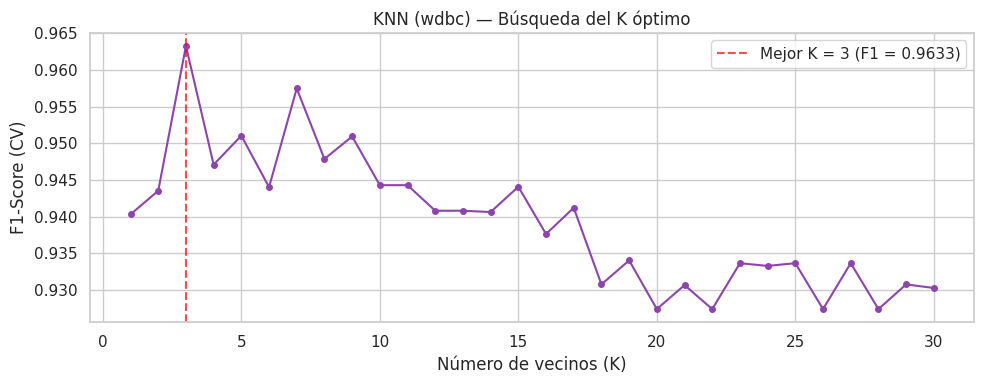

K óptimo: 3
F1 CV con K=1: 0.9403  |  K=3: 0.9633  |  K=30: 0.9303


In [44]:
# 14.8  KNN: búsqueda del K óptimo
k_scores_bc = []
for k in k_range:
    pipe_knn = Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    k_scores_bc.append(cross_val_score(pipe_knn, X_train_bc, y_train_bc, cv=cv, scoring='f1').mean())

best_k_bc = k_range[np.argmax(k_scores_bc)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_range, k_scores_bc, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k_bc, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k_bc} (F1 = {max(k_scores_bc):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN (wdbc) — Búsqueda del K óptimo')
ax.legend()
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k_bc}')
print(f'F1 CV con K=1: {k_scores_bc[0]:.4f}  |  K={best_k_bc}: {max(k_scores_bc):.4f}  |  K=30: {k_scores_bc[-1]:.4f}')

In [45]:
# 14.9  Mejor kernel del SVM e impacto de la estandarización
best_kernel_bc = max(['linear', 'rbf', 'poly'], key=lambda k: results_bc[f'SVM ({k})'].mean())

svm_sin_escala = SVC(kernel=best_kernel_bc, class_weight='balanced', random_state=RANDOM_STATE)
scores_sin_escala = cross_val_score(svm_sin_escala, X_train_bc, y_train_bc, cv=cv, scoring='f1')
f1_con = results_bc[f'SVM ({best_kernel_bc})'].mean()

print(f'Mejor kernel: {best_kernel_bc}')
print(f'CON StandardScaler: F1 = {f1_con:.4f}  |  SIN StandardScaler: F1 = {scores_sin_escala.mean():.4f}')
print(f'Diferencia: {(f1_con - scores_sin_escala.mean())*100:+.2f} puntos porcentuales')

Mejor kernel: rbf
CON StandardScaler: F1 = 0.9583  |  SIN StandardScaler: F1 = 0.8804
Diferencia: +7.79 puntos porcentuales


In [46]:
# 14.10  Entrenamiento final de los 4 modelos y predicciones en test
pipe_knn_bc = Pipeline([('scaler', StandardScaler()),
                        ('clf', KNeighborsClassifier(n_neighbors=best_k_bc))])
results_bc[f'KNN (K={best_k_bc})'] = cross_val_score(pipe_knn_bc, X_train_bc, y_train_bc,
                                                     cv=cv, scoring='f1')
models_bc = {
    'Logistic Regression':      pipelines_bc['Logistic Regression'],
    'Decision Tree':            pipelines_bc['Decision Tree'],
    f'SVM ({best_kernel_bc})':  pipelines_bc[f'SVM ({best_kernel_bc})'],
    f'KNN (K={best_k_bc})':     pipe_knn_bc
}

preds_bc = {}
for name, pipe in models_bc.items():
    pipe.fit(X_train_bc, y_train_bc)
    preds_bc[name] = pipe.predict(X_test_bc)
print('Modelos entrenados:', list(models_bc.keys()))

Modelos entrenados: ['Logistic Regression', 'Decision Tree', 'SVM (rbf)', 'KNN (K=3)']


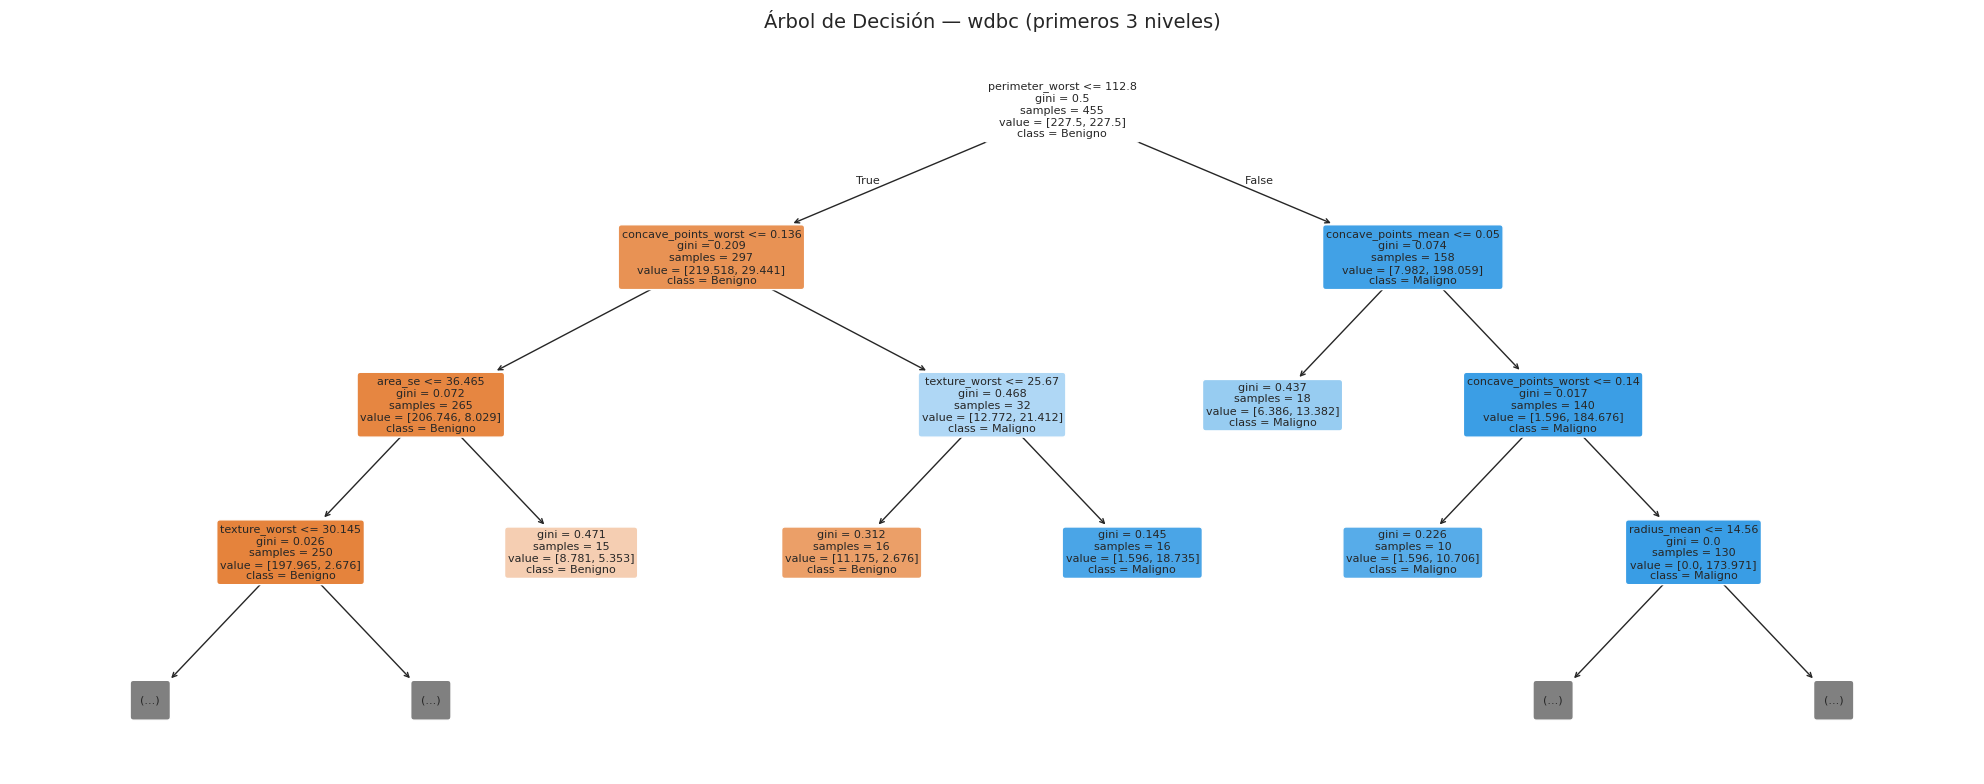

In [47]:
# 14.11  Visualización del Árbol de Decisión
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    models_bc['Decision Tree'].named_steps['clf'],
    feature_names=list(X_bc.columns),
    class_names=['Benigno', 'Maligno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión — wdbc (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

#### Evaluación y comparación
Tabla resumen, matrices de confusión, curvas ROC y classification report en el test. A la tabla se le agregaron el recall de la clase Maligno, el AUC y los errores: FP (benigno predicho como maligno) y FN (maligno predicho como benigno).

In [48]:
# 14.12  Tabla resumen
summary_bc = []
for name, pipe in models_bc.items():
    y_pred = preds_bc[name]
    tn, fp, fn, tp = confusion_matrix(y_test_bc, y_pred).ravel()
    auc = roc_auc_score(y_test_bc, pipe.predict_proba(X_test_bc)[:, 1])
    summary_bc.append({
        'Modelo': name,
        'F1 CV (mean)': f'{results_bc[name].mean():.4f}',
        'F1 CV (std)': f'{results_bc[name].std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test_bc, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test_bc, y_pred):.4f}',
        'Recall Maligno': f'{recall_score(y_test_bc, y_pred):.4f}',
        'AUC Test': f'{auc:.4f}',
        'FP': fp, 'FN': fn
    })

print('='*105)
print('COMPARACIÓN DE MODELOS — WDBC   (FP = benigno predicho maligno | FN = maligno predicho benigno)')
print('='*105)
print(pd.DataFrame(summary_bc).to_string(index=False))

COMPARACIÓN DE MODELOS — WDBC   (FP = benigno predicho maligno | FN = maligno predicho benigno)
             Modelo F1 CV (mean) F1 CV (std) Accuracy Test F1 Test Recall Maligno AUC Test  FP  FN
Logistic Regression       0.9616      0.0241        0.9737  0.9639         0.9524   0.9954   1   2
      Decision Tree       0.9255      0.0296        0.9298  0.9024         0.8810   0.9869   3   5
          SVM (rbf)       0.9583      0.0154        0.9825  0.9762         0.9762   0.9954   1   1
          KNN (K=3)       0.9633      0.0250        0.9386  0.9114         0.8571   0.9825   1   6


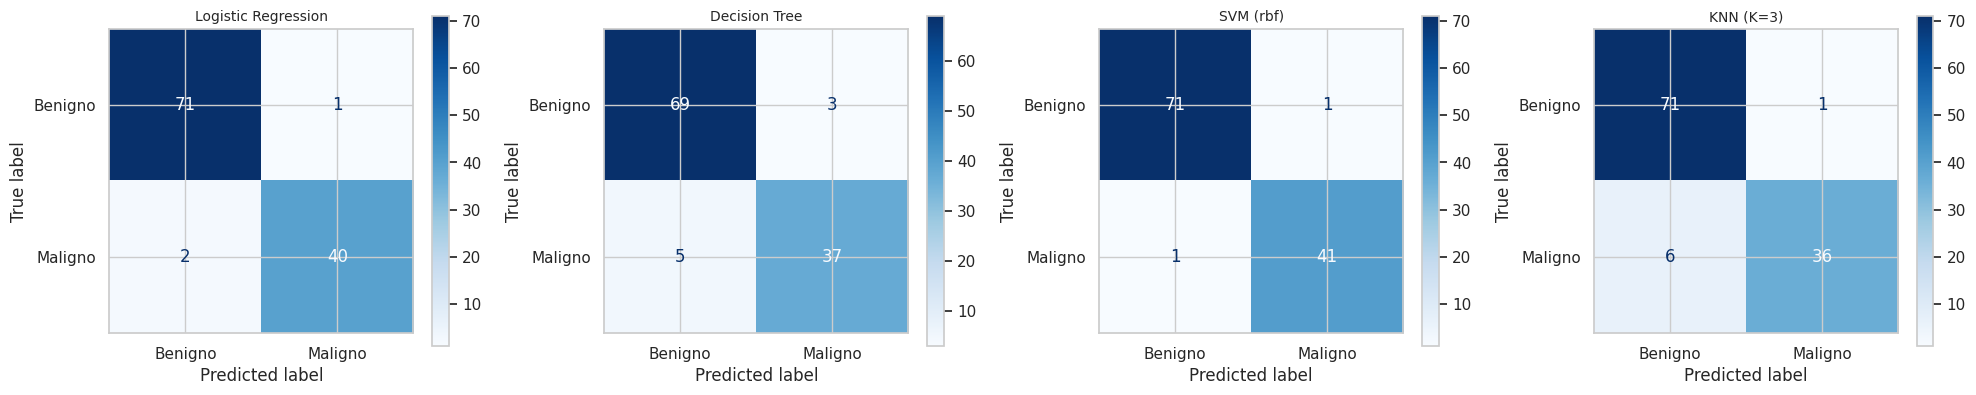

In [49]:
# 14.13  Matrices de confusión
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, y_pred) in zip(axes, preds_bc.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test_bc, y_pred, display_labels=['Benigno', 'Maligno'], cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

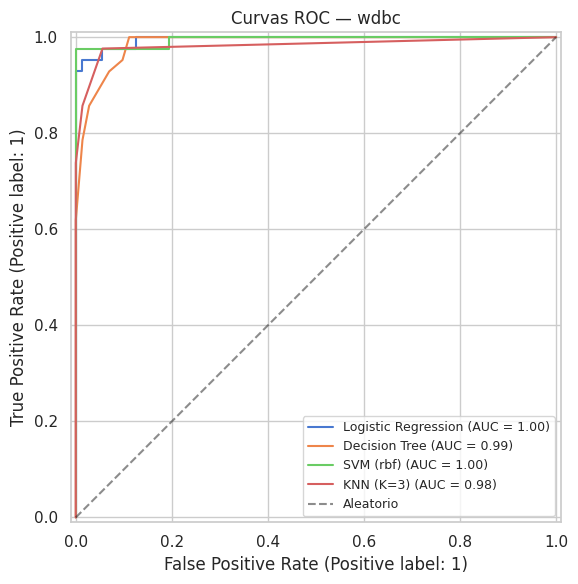

In [50]:
# 14.14  Curvas ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in models_bc.items():
    RocCurveDisplay.from_estimator(pipe, X_test_bc, y_test_bc, ax=ax, name=name)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — wdbc')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [51]:
# 14.15  Classification report de cada modelo
mejor_bc = max(models_bc, key=lambda k: results_bc[k].mean())
print(f'Mejor modelo por F1 CV (criterio de la sesión): {mejor_bc}\n')

for name in models_bc:
    print('='*60)
    print(name)
    print('='*60)
    print(classification_report(y_test_bc, preds_bc[name], target_names=['Benigno', 'Maligno']))

Mejor modelo por F1 CV (criterio de la sesión): KNN (K=3)

Logistic Regression
              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Decision Tree
              precision    recall  f1-score   support

     Benigno       0.93      0.96      0.95        72
     Maligno       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

SVM (rbf)
              precision    recall  f1-score   support

     Benigno       0.99      0.99      0.99        72
     Maligno       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98  

#### Análisis comparativo

| Modelo | F1 CV | Accuracy Test | F1 Test | Recall Maligno | AUC | FP | FN |
|---|---|---|---|---|---|---|---|
| Logistic Regression | 0.9616 | 0.9737 | 0.9639 | 0.9524 | 0.9954 | 1 | 2 |
| Decision Tree | 0.9255 | 0.9298 | 0.9024 | 0.8810 | 0.9869 | 3 | 5 |
| SVM (rbf) | 0.9583 | 0.9825 | 0.9762 | 0.9762 | 0.9954 | 1 | 1 |
| KNN (K=3) | 0.9633 | 0.9386 | 0.9114 | 0.8571 | 0.9825 | 1 | 6 |

(FP = benigno predicho como maligno; FN = maligno predicho como benigno)

- **Validación cruzada:** la Regresión Logística (0.9616), el SVM (0.9583) y KNN (0.9633) quedaron prácticamente empatados, con una variación entre folds de 0.015 a 0.025. El Árbol de Decisión quedó más abajo (0.9255).
- **Conjunto de test:** el orden cambia. El SVM fue el mejor (accuracy 0.9825, F1 0.9762), seguido de la Regresión Logística (0.9737 y 0.9639), KNN (0.9386 y 0.9114) y el Árbol (0.9298 y 0.9024). KNN, que era el primero en validación cruzada, quedó tercero en test.
- **Matrices de confusión:** todos los modelos tienen pocos falsos positivos (entre 1 y 3). La diferencia está en los falsos negativos, que son el error más grave porque son tumores malignos no detectados: SVM 1, Regresión Logística 2, Árbol 5 y KNN 6.
- **Curvas ROC y AUC:** las cuatro curvas quedan muy cerca de la esquina superior izquierda, con AUC entre 0.9825 y 0.9954 (0.9954 en la Regresión Logística y el SVM). Todos los modelos separan muy bien las dos clases y las diferencias entre ellos son pequeñas.
- **Ajustes dentro de cada modelo:**
  - SVM: el kernel rbf (0.9583) fue mejor que el lineal (0.9523) y que el poly (0.8820 ± 0.0591).
  - SVM: sin estandarizar el F1 baja a 0.8804, es decir, 7.79 puntos menos.
  - KNN: el mejor K fue 3 (0.9633), mientras que K=1 dio 0.9403 y K=30 dio 0.9303.
- **¿Cuál es el mejor modelo?** No se puede decidir por un solo número. La regla de la sesión (mayor F1 de CV) elegiría KNN, pero en el test fue el que más tumores malignos dejó pasar. Considerando F1, recall de la clase maligna, AUC y la coherencia entre validación cruzada y test, los más sólidos fueron el **SVM (rbf)** y la **Regresión Logística**.

#### Hallazgos

- El dataset tiene 569 registros y 30 features, sin valores nulos ni duplicados. Hay 357 tumores benignos y 212 malignos (proporción 1.68:1), un desbalance leve. La variable `Diagnosis` se convirtió a 0/1 y el `ID` se excluyó de las features.
- Los tumores malignos tienen valores mucho más altos en tamaño y concavidad (`concavity_mean` +249 %, `area_se` +244 %, `concave_points_mean` +242 %), mientras que `fractal_dimension_mean`, `symmetry_se` y `texture_se` casi no cambian (entre −0.3 % y −0.8 %).
- Hay mucha redundancia entre variables: 21 de los 435 pares de features tienen correlación de 0.90 o más.
- Los cuatro modelos funcionaron bien (F1 de test entre 0.9024 y 0.9762), pero ninguno fue perfecto: se equivocaron entre 2 y 8 tumores de los 114 del test.
- El SVM (rbf) y la Regresión Logística fueron los mejores, y tienen el mismo AUC (0.9954). El Árbol y KNN dejaron pasar más tumores malignos (5 y 6 falsos negativos).
- La estandarización fue importante: `area_worst` llega a 4254 y `smoothness_worst` no pasa de 0.2226, y sin estandarizar el SVM perdió casi 8 puntos de F1.
- Un modelo más flexible no fue mejor: el kernel poly fue el peor de los SVM y el más inestable.
- El test es pequeño (114 casos, 42 malignos), así que un solo error mueve casi 0.9 puntos de accuracy. Las diferencias de 1 o 2 casos entre modelos no son concluyentes.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*